In [5]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy, pickle
from tqdm import tqdm
from scipy import ndimage

In [ ]:
# Trajectory grid bounds and map resolution.
# 1000 points per trajectory / 32x32 bins ~= 1 raw sample per bin before smoothing —
# fine enough to resolve field structure without every bin being empty.
BOUNDS = (0.0, 1.0)
N_BINS = 40
SIGMA = 0.5     # Gaussian smoothing bandwidth, in bins
EPS = 1e-12

SKIP_TIMESTEPS = 50


SI_THRESHOLD = 0
SPARSITY_THRESHOLD = 0


#### Data extraction

In [14]:
def occupancy_map_func(pos, reso=40, win_len=9, debug=False):
    """
    Calculate occupancy map.

    Parameters
    ----------
    pos : (N,2)
        x,y positions

    reso : int
        Half the number of bins (total bins = 2*reso)

    debug : bool
        If True, print diagnostics and plot intermediate results.
    """

    if debug:
        print("=" * 50)
        print("INPUT")
        print("=" * 50)
        print("Position shape:", pos.shape)
        print(f"x range: [{pos[:,0].min():.3f}, {pos[:,0].max():.3f}]")
        print(f"y range: [{pos[:,1].min():.3f}, {pos[:,1].max():.3f}]")
        print()

    # ---------------------------------------------------------
    # Raw occupancy histogram
    # ---------------------------------------------------------

    H1, xedges, yedges = np.histogram2d(
        pos[:, 0],
        pos[:, 1],
        bins=reso * 2,
    )

    if debug:
        print("=" * 50)
        print("RAW HISTOGRAM")
        print("=" * 50)
        print("Shape:", H1.shape)
        print("Total visits:", H1.sum())
        print("Maximum bin:", H1.max())
        print("Occupied bins:", np.count_nonzero(H1))

        plt.figure(figsize=(5,5))
        plt.imshow(H1.T, origin="lower")
        plt.title("Raw Occupancy Histogram")
        plt.colorbar()
        plt.show()

    # ---------------------------------------------------------
    # Gaussian
    # ---------------------------------------------------------

    gaussian = matlab_style_gauss2D((win_len, win_len), sigma=3)

    if debug:
        print("=" * 50)
        print("GAUSSIAN")
        print("=" * 50)
        print("Shape:", gaussian.shape)
        print("Sum:", gaussian.sum())

        plt.figure(figsize=(4,4))
        plt.imshow(gaussian)
        plt.title("Gaussian Kernel")
        plt.colorbar()
        plt.show()

    # ---------------------------------------------------------
    # Convolution
    # ---------------------------------------------------------

    conv = scipy.signal.convolve2d(
        gaussian,
        H1,
    )

    if debug:
        print("=" * 50)
        print("AFTER CONVOLUTION")
        print("=" * 50)
        print("Shape:", conv.shape)

        plt.figure(figsize=(5,5))
        plt.imshow(conv.T, origin="lower")
        plt.title("Smoothed Occupancy")
        plt.colorbar()
        plt.show()

    # ---------------------------------------------------------
    # Crop
    # ---------------------------------------------------------

    pos_prob = conv[
        int(win_len/2):-int(win_len/2),
        int(win_len/2):-int(win_len/2)
    ]

    if debug:
        print("=" * 50)
        print("AFTER CROPPING")
        print("=" * 50)
        print("Shape:", pos_prob.shape)

        plt.figure(figsize=(5,5))
        plt.imshow(pos_prob.T, origin="lower")
        plt.title("After Cropping")
        plt.colorbar()
        plt.show()

    # ---------------------------------------------------------
    # Normalize
    # ---------------------------------------------------------

    total = np.nansum(pos_prob)

    if debug:
        print("Sum before normalization:", total)

    pos_prob = pos_prob / total

    if debug:
        print("Sum after normalization:", np.nansum(pos_prob))

    # ---------------------------------------------------------
    # Mask empty bins
    # ---------------------------------------------------------

    pos_prob[pos_prob == 0] = np.nan

    if debug:
        print("=" * 50)
        print("FINAL OCCUPANCY MAP")
        print("=" * 50)
        print("NaNs:", np.isnan(pos_prob).sum())
        print("Finite bins:", np.isfinite(pos_prob).sum())

        plt.figure(figsize=(6,6))
        plt.imshow(pos_prob.T, origin="lower")
        plt.title("Final Occupancy Map")
        plt.colorbar()
        plt.show()

    return pos_prob

In [15]:
def firing_rate_map_place_cells(
    resp_neurons,
    positions,
    occupancy_map,
    thresh_param=0.0,
    title="",
    ticks_colbar=None,
    res_param=40,
    sub_plot=False,
    debug=False,
):
    """
    Compute firing rate map with optional debugging.
    """

    res = res_param

    mean_resp = np.mean(resp_neurons)
    std_resp = np.std(resp_neurons)
    thresh = mean_resp + thresh_param * std_resp

    firr = np.nonzero(resp_neurons > thresh)

    firposgrid = positions[firr[0], :2]
    firingvalue = resp_neurons[firr]

    if debug:
        print("="*60)
        print("Neuron statistics")
        print("="*60)
        print(f"Mean activation      : {mean_resp:.5f}")
        print(f"Std activation       : {std_resp:.5f}")
        print(f"Threshold            : {thresh:.5f}")
        print(f"Total samples        : {len(resp_neurons)}")
        print(f"Samples above thresh : {len(firingvalue)}")
        print(f"Percentage           : {100*len(firingvalue)/len(resp_neurons):.2f}%")
        print()

    # ----------------------------------------------------
    # Plot spike locations
    # ----------------------------------------------------

    if debug:

        plt.figure(figsize=(6,6))

        plt.scatter(
            positions[:,0],
            positions[:,1],
            s=1,
            alpha=0.15,
            label="trajectory"
        )

        plt.scatter(
            firposgrid[:,0],
            firposgrid[:,1],
            s=6,
            c="red",
            label="selected"
        )

        plt.legend()
        plt.axis("equal")
        plt.title("Thresholded activity")
        plt.show()

    # ----------------------------------------------------

    x = np.arange(-1, 1, 1/res)
    y = np.arange(-1, 1, 1/res)

    fx, fy = np.meshgrid(x, y)

    firingmap = np.zeros(fx.shape)

    visited = {}

    for ii in range(len(firposgrid)):

        q1 = np.argmin(np.abs(firposgrid[ii,0] - fx[1,:]))
        q2 = np.argmin(np.abs(firposgrid[ii,1] - fy[:,1]))

        if debug and ii < 15:

            print(
                f"{ii:3d}: "
                f"({firposgrid[ii,0]: .3f}, {firposgrid[ii,1]: .3f}) "
                f"-> bin ({q1:2d},{q2:2d}) "
                f"value={firingvalue[ii]:.4f}"
            )

        visited[(q1,q2)] = visited.get((q1,q2),0) + 1

        firingmap[q1,q2] = max(
            firingvalue[ii],
            firingmap[q1,q2]
        )

    if debug:

        print()
        print("="*60)
        print("Bin statistics")
        print("="*60)
        print("Unique bins:", len(visited))
        print("Total spikes:", len(firingvalue))
        print("Maximum spikes in one bin:", max(visited.values()))

        plt.figure(figsize=(6,6))
        plt.imshow(firingmap.T, origin="lower")
        plt.colorbar()
        plt.title("Before occupancy normalization")
        plt.show()

    print("Occupancy statistics")
    print("--------------------")
    print("min:", np.nanmin(occupancy_map))
    print("max:", np.nanmax(occupancy_map))
    print("mean:", np.nanmean(occupancy_map))

    print()

    print("Firing map statistics BEFORE division")
    print(np.nanmin(firingmap))
    print(np.nanmax(firingmap))
    
    occupancy = occupancy_map + EPS

    firingmap = firingmap / occupancy

    print()

    print("After division")
    print(np.nanmin(firingmap))
    print(np.nanmax(firingmap))

    gaussian = matlab_style_gauss2D((9,9),3)

    spikes_smooth = scipy.signal.convolve2d(
        gaussian,
        firingmap
    )

    rotated_img = ndimage.rotate(spikes_smooth,90)

    win_len = 9

    rotated_img = rotated_img[
        int(win_len/2):-int(win_len/2),
        int(win_len/2):-int(win_len/2)
    ]

    if not sub_plot:

        plt.imshow(rotated_img,cmap="jet")
        plt.colorbar()
        plt.title(title)
        plt.show()

    return rotated_img

In [16]:
def matlab_style_gauss2D(shape,sigma):
    """
    2D gaussian mask - should give the same result as MATLAB's
    fspecial('gaussian',[shape],[sigma])
    """
    m,n = [(ss-1.)/2. for ss in shape]
    y,x = np.ogrid[-m:m+1,-n:n+1]
    h = np.exp( -(x*x + y*y) / (2.*sigma*sigma) )
    h[ h < np.finfo(h.dtype).eps*h.max() ] = 0
    sumh = h.sum()
    if sumh != 0:
      h /= sumh
    return h

In [17]:
def get_input_data(
    pkl_path,
    layer_name,
    representation="real",
):

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    # Choose trajectory positions
    positions = np.asarray(data["prediction"])
    # or:
    # positions = np.asarray(data["ground_truth"])

    activations = np.asarray(data[layer_name])

    # ------------------------------------
    # Convert representation if necessary
    # ------------------------------------

    if np.iscomplexobj(activations):

        if representation == "real":
            activations = activations.real

        elif representation == "imag":
            activations = activations.imag

        elif representation == "phase":
            activations = np.angle(activations)

        elif representation == "magnitude":
            activations = np.abs(activations)

        else:
            raise ValueError("Unknown representation")
        
    if SKIP_TIMESTEPS > 0:
        positions = positions[:, SKIP_TIMESTEPS:, :]
        activations = activations[:, SKIP_TIMESTEPS:, :]


    return positions, activations

### Identifying place cells

#### Download DONN activations & extract corresponding positions

In [27]:
# Get input data
pkl_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"


layer_name = "d4"
representation = "magnitude"  # Options: "real", "imag", "phase", "magnitude", "auto"



# 1. Load data
positions, activations = get_input_data(
    pkl_path,
    layer_name=layer_name,
    representation=representation,
)

# 2. Flatten trajectories
positions = positions.reshape(-1, 2)
activations = activations.reshape(-1, activations.shape[-1])

print("Positions   :", positions.shape)
print("Activations :", activations.shape)






Positions   : (225000, 2)
Activations : (225000, 100)


In [28]:
print(data["d4"].dtype)
print(np.iscomplexobj(data["d4"]))

NameError: name 'data' is not defined

INPUT
Position shape: (225000, 2)
x range: [0.028, 0.969]
y range: [0.030, 0.958]

RAW HISTOGRAM
Shape: (80, 80)
Total visits: 225000.0
Maximum bin: 98.0
Occupied bins: 6029


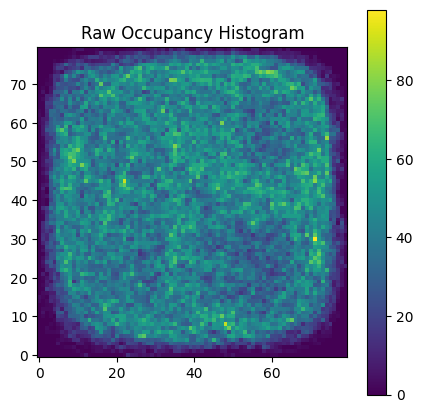

GAUSSIAN
Shape: (9, 9)
Sum: 0.9999999999999999


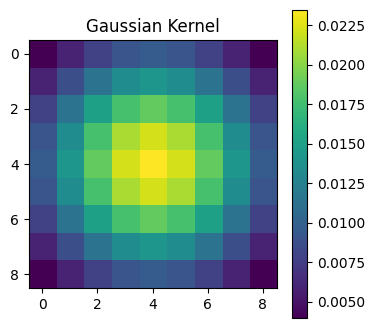

AFTER CONVOLUTION
Shape: (88, 88)


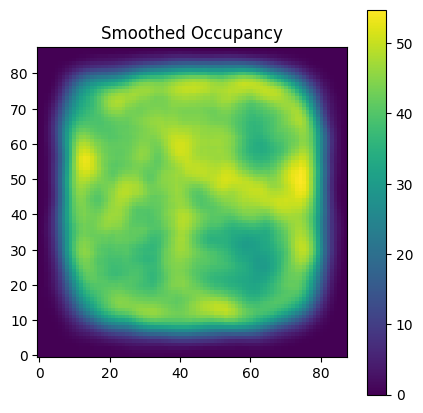

AFTER CROPPING
Shape: (80, 80)


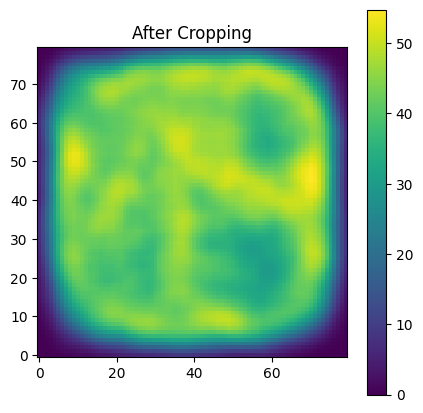

Sum before normalization: 223485.91916614916
Sum after normalization: 1.0
FINAL OCCUPANCY MAP
NaNs: 6
Finite bins: 6394


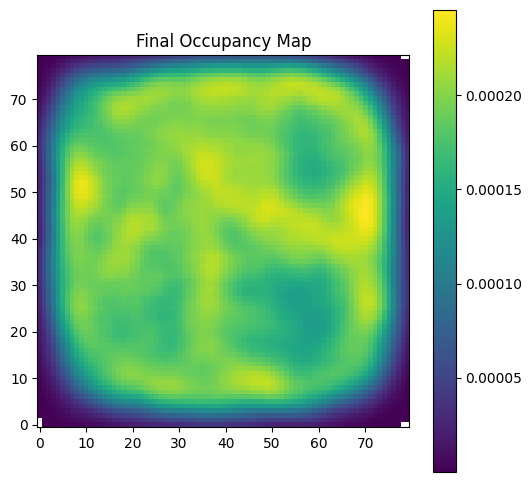

In [25]:
# 3. Compute occupancy map
occupancy_map = occupancy_map_func(
    positions,
    reso=40,
    win_len=9,
    debug=True,      # optional if you added the debug version
)

Neuron statistics
Mean activation      : 0.35626
Std activation       : 1.80318
Threshold            : 3.06103
Total samples        : 225000
Samples above thresh : 2930
Percentage           : 1.30%



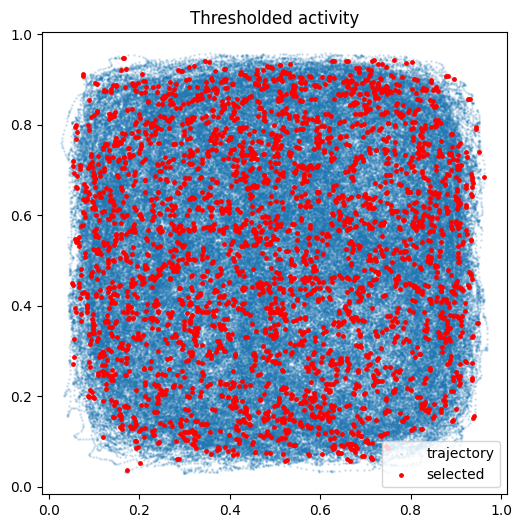

  0: ( 0.725,  0.280) -> bin (69,51) value=3.0913
  1: ( 0.727,  0.285) -> bin (69,51) value=3.1388
  2: ( 0.891,  0.750) -> bin (76,70) value=3.0942
  3: ( 0.291,  0.116) -> bin (52,45) value=3.0723
  4: ( 0.296,  0.110) -> bin (52,44) value=3.1173
  5: ( 0.677,  0.825) -> bin (67,73) value=3.0757
  6: ( 0.690,  0.824) -> bin (68,73) value=3.1213
  7: ( 0.709,  0.504) -> bin (68,60) value=3.0961
  8: ( 0.101,  0.524) -> bin (44,61) value=3.0808
  9: ( 0.098,  0.526) -> bin (44,61) value=3.1238
 10: ( 0.717,  0.225) -> bin (69,49) value=3.0638
 11: ( 0.717,  0.224) -> bin (69,49) value=3.1084
 12: ( 0.192,  0.138) -> bin (48,46) value=3.0863
 13: ( 0.190,  0.145) -> bin (48,46) value=3.1333
 14: ( 0.554,  0.905) -> bin (62,76) value=3.1011

Bin statistics
Unique bins: 999
Total spikes: 2930
Maximum spikes in one bin: 11


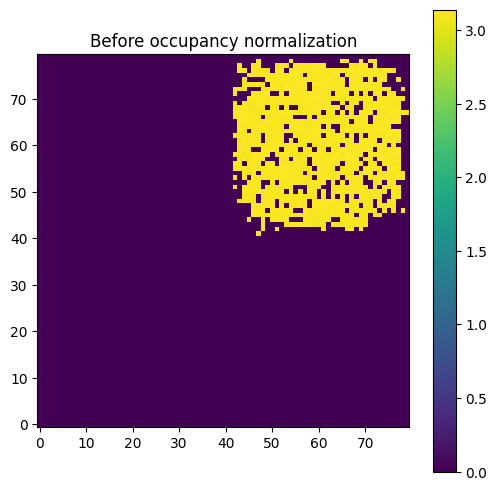

Occupancy statistics
--------------------
min: 1.774271343323204e-08
max: 0.0002452184797658998
mean: 0.00015639662183296842

Firing map statistics BEFORE division
0.0
3.1415765285491943

After division
0.0
597615.558363776


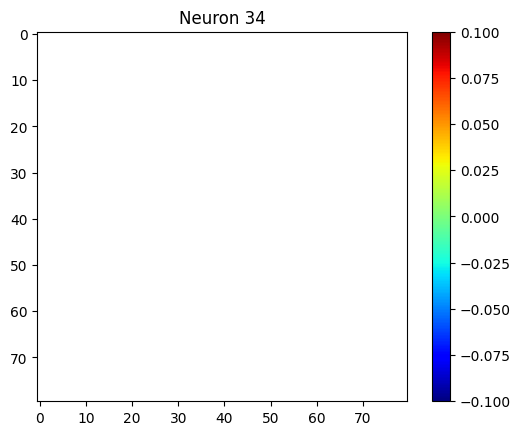

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [26]:
neuron = 34

# 5. Compute firing-rate map
firing_rate_map_place_cells(
    resp_neurons=activations[:, neuron],
    positions=positions,
    occupancy_map=occupancy_map.copy(),
    thresh_param=1.5,
    debug=True,
    title=f"Neuron {neuron}",
)